# 05 · Integration

In this notebook you will:

- put the four themes side by side in one figure
- test the prediction the whole course has been building towards: **does each
  perturbation move its own theme most?**
- see which markers travel together across perturbations, and whether that grouping
  matches the panels we assigned by hand
- connect the marker-level and composition-level results

This is the chapter where the separation into themes has to justify itself.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

from mcs2026 import analysis, panels, plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

wells = pd.read_parquet(H5AD_SLIM.with_name("mcs2026_wells.parquet"))
cells = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_clean.h5ad"))
proportions = pd.read_parquet(H5AD_SLIM.with_name("mcs2026_proportions.parquet"))

## 1. The four themes in one table

Each theme chapter saved one number per condition: the mean absolute shift from DMSO
across that panel, in control-well standard deviations.

In [2]:
summaries = {}
for theme in panels.THEMES:
    markers = analysis.panel_markers(theme, wells.columns)
    summaries[theme] = analysis.theme_summary(wells, markers)

overview = pd.DataFrame(summaries)
overview = overview.drop(index=analysis.OUTLIER_CONDITION, errors="ignore")
overview = overview.sort_values(list(overview.columns), ascending=False)
overview.round(2)

,signaling,mechanics,metabolism,organelles
condition,,,,
Cycloheximide,2.25,1.33,1.01,1.25
Sapanisertib/INK128,2.01,1.31,1.76,1.20
MK-2206,1.61,1.38,1.20,0.90
Pd17,1.26,1.21,1.45,1.78
Geldanamycin,1.18,0.91,0.58,0.88
RA,1.16,0.50,0.16,0.60
LipidMix,0.93,0.92,0.57,0.64
Wortmannin,0.80,0.69,0.37,0.63
IL6,0.74,0.19,0.48,0.63


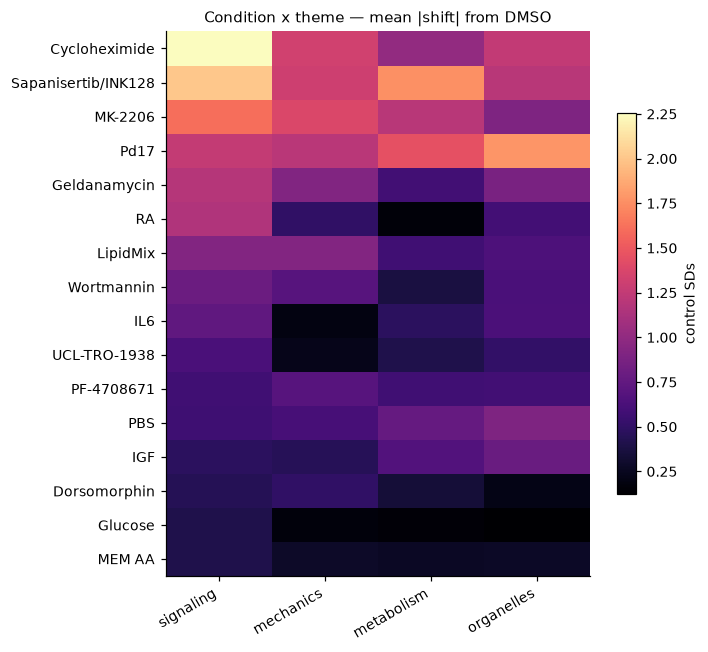

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 6))
im = ax.imshow(overview.values, cmap="magma", aspect="auto")
ax.set(yticks=range(len(overview)), yticklabels=overview.index)
ax.set_xticks(range(len(overview.columns)))
ax.set_xticklabels(overview.columns, rotation=30, ha="right")
ax.set_title("Condition x theme — mean |shift| from DMSO")
fig.colorbar(im, ax=ax, shrink=0.7, label="control SDs")
fig.tight_layout()

## 2. The prediction

The compounds were chosen to hit specific processes. If the four panels measure what
their names claim, a compound should move its own theme more than the others.

Write the expectation down **before** looking.

In [4]:
expected = {
    "MK-2206": "signaling",                    # AKT inhibitor
    "Wortmannin": "signaling",                 # PI3K inhibitor
    "Sapanisertib/INK128": "signaling",        # mTOR inhibitor
    "PF-4708671": "signaling",                 # S6K1 inhibitor
    "IGF": "signaling",                        # pathway activator
    "Glucose": "metabolism",
    "LipidMix": "metabolism",
    "MEM AA": "metabolism",
    "UCL-TRO-1938": "metabolism",
    "Geldanamycin": "metabolism",              # HSP90 inhibitor
}
pd.Series(expected, name="expected theme").to_frame()

,expected theme
MK-2206,signaling
Wortmannin,signaling
Sapanisertib/INK128,signaling
PF-4708671,signaling
IGF,signaling
Glucose,metabolism
LipidMix,metabolism
MEM AA,metabolism
UCL-TRO-1938,metabolism
Geldanamycin,metabolism


In [5]:
ranked = overview.rank(axis=1, ascending=False)

# Only the conditions we made a prediction for, and only those present in the table.
predicted = [c for c in expected if c in overview.index]
check = pd.DataFrame({
    "expected": [expected[c] for c in predicted],
    "strongest theme": [overview.loc[c].idxmax() for c in predicted],
    "rank of expected": [ranked.loc[c, expected[c]] for c in predicted],
}, index=predicted)
check["as predicted"] = check["expected"] == check["strongest theme"]
check

,expected,strongest theme,rank of expected,as predicted
MK-2206,signaling,signaling,1.0,True
Wortmannin,signaling,signaling,1.0,True
Sapanisertib/INK128,signaling,signaling,1.0,True
PF-4708671,signaling,mechanics,4.0,False
IGF,signaling,organelles,3.0,False
Glucose,metabolism,signaling,3.0,False
LipidMix,metabolism,signaling,4.0,False
MEM AA,metabolism,signaling,4.0,False
UCL-TRO-1938,metabolism,signaling,3.0,False
Geldanamycin,metabolism,signaling,4.0,False


In [6]:
hits = int(check["as predicted"].sum())
print(f"{hits} of {len(check)} compounds moved their own theme most")
print(f"by chance alone you would expect about {len(check) / 4:.1f}")
print(f"\nmean rank of the expected theme (1 = best of 4): "
      f"{check['rank of expected'].mean():.2f}")

3 of 10 compounds moved their own theme most
by chance alone you would expect about 2.5

mean rank of the expected theme (1 = best of 4): 2.80


### Reading the result honestly

The prediction is **partly** borne out — and the failures are more informative than the
successes. Note the split: every compound targeting the PI3K-AKT-mTOR axis ranks
signaling first, and every metabolic supplement does not.

**The signaling compounds mostly behave.** The PI3K–AKT–mTOR inhibitors move the
signaling panel strongly — and they also move metabolism, because p-S6 and p-AKT sit
in both panels by design. That is not a failure of the prediction; it is the overlap
working as intended.

**The metabolic supplements do not.** Glucose, LipidMix, MEM AA and UCL-TRO-1938 sit
near the bottom of every column. [Chapter 03](03_metabolism.ipynb) explained why: these antibodies measure
**protein abundance**, and adding a nutrient changes metabolic *flux* long before it
changes how much mitochondrial or chaperone protein a cell contains.

:::{important}
A panel is named after the biology you hope it reports, but it measures what the
antibodies bind. When the two diverge, the panel name is the thing that is wrong.
:::

## 3. Are the themes actually distinct?

We assigned markers to panels using prior knowledge. The data can be asked whether that
grouping is real: do markers within a theme move together across perturbations?

In [7]:
all_markers = sorted({
    marker
    for theme in panels.THEMES
    for marker in analysis.panel_markers(theme, wells.columns)
})
effects = analysis.effect_table(wells, all_markers, by_timepoint=False)
effects = effects.drop(index=analysis.OUTLIER_CONDITION, errors="ignore")
correlation = effects.corr(method="spearman")
print(f"{len(all_markers)} markers x {len(effects)} conditions")

28 markers x 16 conditions


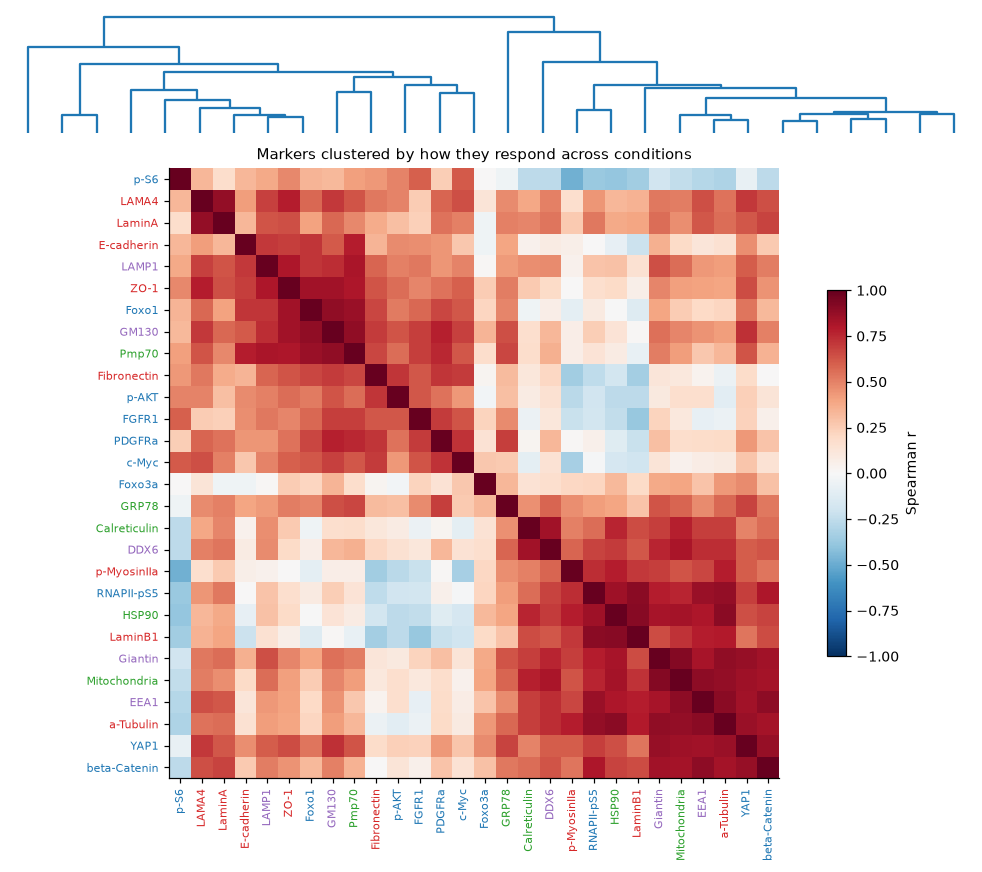

In [8]:
from scipy.cluster.hierarchy import dendrogram, leaves_list, linkage
from scipy.spatial.distance import squareform

distance = 1 - correlation.fillna(0)
np.fill_diagonal(distance.values, 0)
tree = linkage(squareform(distance.values, checks=False), method="average")
order = [correlation.index[i] for i in leaves_list(tree)]

theme_of = {}
for theme in panels.THEMES:
    for marker in analysis.panel_markers(theme, wells.columns):
        theme_of.setdefault(marker, theme)

fig, axes = plt.subplots(2, 1, figsize=(9, 8), height_ratios=[1, 5])
dendrogram(tree, labels=correlation.index.to_list(), ax=axes[0], color_threshold=0)
axes[0].set_xticks([]); axes[0].set_yticks([])
for spine in axes[0].spines.values():
    spine.set_visible(False)

im = axes[1].imshow(correlation.loc[order, order].values, cmap="RdBu_r", vmin=-1, vmax=1)
palette = dict(zip(panels.THEMES, ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]))
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(order, rotation=90, fontsize=7)
axes[1].set_yticks(range(len(order)))
axes[1].set_yticklabels(order, fontsize=7)
for tick, marker in zip(axes[1].get_yticklabels(), order):
    tick.set_color(palette.get(theme_of.get(marker), "0.4"))
for tick, marker in zip(axes[1].get_xticklabels(), order):
    tick.set_color(palette.get(theme_of.get(marker), "0.4"))
axes[1].set_title("Markers clustered by how they respond across conditions")
fig.colorbar(im, ax=axes[1], shrink=0.6, label="Spearman r")
fig.tight_layout()

Label colours are the theme we assigned by hand; the ordering is what the data
produced. Where a colour block holds together, prior knowledge and measurement agree.
Where colours interleave, they do not — and each of those is worth a moment's thought
rather than a shrug.

Markers respond together for reasons that cut across our categories: shared protein
half-life, shared dependence on growth rate, or simply being imaged in the same round
and sharing its artefacts.

In [9]:
within, between = [], []
for i, first in enumerate(all_markers):
    for second in all_markers[i + 1:]:
        value = correlation.loc[first, second]
        if np.isnan(value):
            continue
        (within if theme_of.get(first) == theme_of.get(second) else between).append(value)

print(f"mean correlation within a theme:  {np.mean(within):+.3f}  (n = {len(within)})")
print(f"mean correlation between themes:  {np.mean(between):+.3f}  (n = {len(between)})")

mean correlation within a theme:  +0.378  (n = 93)
mean correlation between themes:  +0.396  (n = 285)


**The within-theme correlation is not higher than the between-theme one.** On this
plate it is very slightly *lower*.

That is a real result and it should change how the four themes are described. They are
**a useful way to organise thinking and to keep the analysis in memory** — one theme at
a time is 600 columns instead of 2,500 — but they are **not four independent
measurements of four separable processes**. The data does not support saying that a
compound is "metabolic but not mechanical".

Why the panels do not separate:

- **Shared upstream control.** Growth signaling sets protein synthesis rate, which
  moves abundance in every panel at once.
- **Shared turnover.** [Chapter 02](02_mechanics.ipynb) found E-cadherin falling and Lamin B1 rising under
  the same treatment, for reasons of half-life rather than function.
- **Shared rounds.** Markers imaged in the same 4i round share that round's artefacts,
  and rounds cut across our biological categories.

:::{important}
This does not invalidate chapters 03–06. Each found specific, replicated, mechanistically
sensible effects. What it invalidates is the stronger claim — that the four panels
measure four independent things. Keep the themes as an organising device and as a
memory strategy; drop them as a claim about independence.
:::

## 4. Markers and composition tell the same story

[Chapter 00](00_full_dataset_analysis.ipynb) found that MK-2206 has the lowest hypoblast fraction. Chapters 01 and 03
found that the PI3K–AKT–mTOR inhibitors have the largest marker effects. Are those the
same conditions?

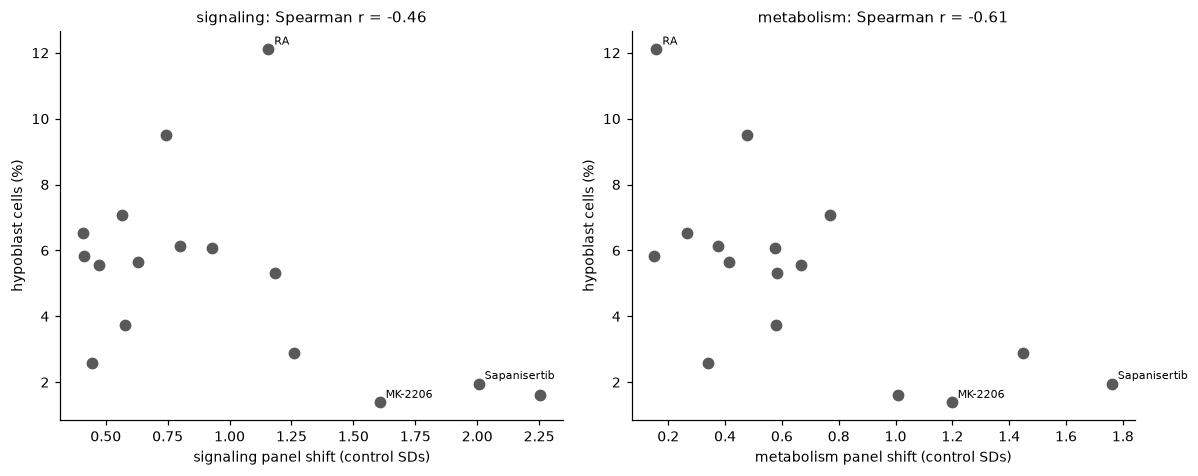

In [10]:
hypoblast = proportions.groupby("condition")["Hypoblast"].mean().mul(100).rename("hypoblast %")
combined = overview.join(hypoblast).dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, theme in zip(axes, ["signaling", "metabolism"]):
    ax.scatter(combined[theme], combined["hypoblast %"], s=45, color="0.35")
    for condition in combined.index:
        if condition in ("DMSO", "MK-2206", "RA", "Sapanisertib/INK128"):
            ax.annotate(condition.split("/")[0][:12],
                        (combined.loc[condition, theme], combined.loc[condition, "hypoblast %"]),
                        fontsize=7, xytext=(4, 3), textcoords="offset points")
    rho = combined[theme].corr(combined["hypoblast %"], method="spearman")
    ax.set(xlabel=f"{theme} panel shift (control SDs)", ylabel="hypoblast cells (%)",
           title=f"{theme}: Spearman r = {rho:+.2f}")
fig.tight_layout()

A negative relationship means: the harder a compound hits these panels, the fewer cells
reach the hypoblast state. Two readings are available, and the data here cannot
separate them:

- the pathway these compounds block is **required** for hypoblast specification; or
- the compounds slow the cells down generally, and differentiation is one of the things
  that stops.

Distinguishing those needs an experiment this plate does not contain — a
dose-response, or a compound that arrests growth without touching the pathway. Saying
so is part of the result.

## 5. What Part 3 found

1. **The decoder works.** 4,464 anonymous columns became named, themed features by
   joining `(channel, round)` to a spreadsheet. Nothing else was possible until that
   was done.
2. **Measurement drifts.** DAPI moves about fifteen-fold across the 18 rounds, so
   intensities are only comparable within a round, against controls that went through
   the same round.
3. **The PI3K–AKT–mTOR axis is the strongest signal in the plate.** INK128 and MK-2206
   lower p-S6 by several control SDs, and Foxo1 falls for every inhibitor of the axis.
4. **p-AKT itself shows nothing** — feedback, and a fragile phospho-epitope in round 24.
   The most useful readout was not the most obvious one.
5. **The same axis controls cell fate.** MK-2206 has the lowest hypoblast fraction of
   any condition; retinoic acid the highest.
6. **PMA is a different experiment**, shifting every marker by 4–11 control SDs.
7. **The replicate unit is the well.** 733,556 cells, 224 wells, 3 per condition per
   timepoint. The same comparison gives p = 1e-18 counted over cells and p = 0.036
   counted over wells. Only the second one is about the treatment.
8. **The four themes do not separate statistically.** Markers within a theme are no
   more correlated than markers across themes. The themes earned their place as a way
   to organise the analysis and to fit it in memory — not as evidence that four
   independent processes were measured.

---

## Exercises

### 1. Add a theme

`cell_cycle` (Cyclin A2, p21, Ki67) was not one of the four. Add it to `overview` and
re-run the correlation. Does proliferation explain any of the other themes?

:::{admonition} Solution
:class: dropdown

```python
extra = analysis.panel_markers("cell_cycle", wells.columns)
overview["cell_cycle"] = analysis.theme_summary(wells, extra)
print(overview.corr(method="spearman").round(2))
```

Watch for a compound that moves everything, cell cycle included. [Chapter 02](02_mechanics.ipynb) showed that
protein abundance depends on dilution by cell division, so anything that slows growth
shifts many markers at once without acting on any of them specifically. Cell cycle is
a **covariate**, and a theme that correlates strongly with it may be reporting growth
rate rather than its own biology.
:::

### 2. Rebuild the panels from the data

Cut the marker dendrogram into four groups and compare them with the four themes. Where
do they disagree, and is the data-driven grouping more biologically sensible or less?

:::{admonition} Solution
:class: dropdown

```python
from scipy.cluster.hierarchy import fcluster
groups = fcluster(tree, t=4, criterion="maxclust")
comparison = pd.DataFrame({"marker": correlation.index, "data_group": groups})
comparison["our_theme"] = comparison.marker.map(theme_of)
print(pd.crosstab(comparison.data_group, comparison.our_theme))
```

Expect partial agreement. Data-driven groups tend to capture *response* similarity —
proteins with similar turnover, or markers from the same imaging round — while our
themes capture *functional* similarity. Neither is the correct answer; they answer
different questions, and the useful move is to notice when a marker's data-driven
neighbours are all from its own round.
:::

### 3. Choose a group project

Take one row of the condition × theme table that surprises you and work out why. The
[group projects](../projects.md) page has five starting points; this table is a good
way to pick one.

---

**Next:** [Group projects](../projects.md) — take one theme further than these notebooks did.